# ML Photometric Redshift Production -- Part II: Result Analysis

**Authors: Zhiyao Li** <zhiyaol@alumni.cmu.edu>, **Markus Michael Rau** <markusmichael.rau@googlemail.com>, **Rachel Mandelbaum** <rmandelb@andrew.cmu.edu>

We validate our Machine Learning Redshift Estimation algorithm that produces photometric redshift estimations for the simulated extragalactic catalog with magnitude errors (cosmoDC2_v1.1.4_small_photoz_magerr_10y)

In [1]:
%pylab inline

import sys
import numpy as np
from numpy.random import shuffle
from matplotlib import pyplot as plt
%matplotlib inline

from sklearn.ensemble import RandomForestClassifier
import itertools
import copy
from astropy.coordinates import SkyCoord
import pandas as pd

import change_path
import GCRCatalogs
from astropy.table import Table

Populating the interactive namespace from numpy and matplotlib


In [2]:
n_bins = 101
z_min = 0
z_max = 3
rz_ind = 1

llinewidth = 5
label_fontsize = 12
title_fontsize = 20
legend_fontsize = 14
tick_fontsize = 13
ppointsize = 8
ccapsize = 12

#Define the reshift grid based on bin arrangements
grid_Y = np.linspace(z_min, z_max, num=n_bins)
delta_z = grid_Y[1:] - grid_Y[:-1]
midpoints = grid_Y[:-1] + delta_z/2

### Load our results obtained from "ML Photometric Redshift Production -- Part I: Model Training"

In [9]:
# Read our result of the whole ensemble

sys_ave =  Table.read('/global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/OLIVIA_WORK/result3_sys.fits')


# Read our result of individual galaxies 

par_loc = '/global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/OLIVIA_WORK/final-result.parquet'
result_data_table = pd.read_parquet(par_loc)


# Loading the training set for analysis purpose

train_dat_dir = '/global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/TESTRUN/sample_cosmodc2_w10year_errors.dat'
train_data = np.loadtxt(train_dat_dir, skiprows=1)
format_train = np.delete(train_data,[16,17],1)

# Limit to the range of reshift value we are inspecting
train = format_train[(format_train[:,rz_ind] >= z_min) & (format_train[:,rz_ind] < z_max) & (format_train[:,10] <= 25.0)]
 #appy to rows individually
training_size = len(train)

#delete no longer needed variables to free up memory
%xdel train_data
%xdel format_train

## Emsemble result analysis
#### We calculate redicted ensemble average photoz and standard deviation and compare with true average redshift

In [8]:
# Calculate Predicted Ensemble Average Photoz and Standard Deviation

from scipy import integrate
ave_list = []
for i in range(50):
    ave_list += [integrate.simps(sys_ave['col0'][i],midpoints)]
mean_ens = np.mean(ave_list)
sigma_ens = np.std(ave_list)

print('Ensemble Photometric Redshift Average = ' + str(mean_ens))
print('Ensemble Photometric Redshift Standard Deviation = ' + str(sigma_ens))


# Calculate True Average Redshift

test = result_data_table['rz_real'].to_list()
test_true = np.histogram(test,n_bins-1)
true_z = test_true[1]
true_p = test_true[0]/(len(test)*(z_max/(n_bins-1)))
true_ave = integrate.simps(true_p,midpoints)
print('Ensemble True Redshift Average = ' + str(true_ave))

# Calcualte the difference between true redshift and predicted redshift
print('Difference between true redshift and predicted redshift = '+ str(mean_ens - true_ave))

Ensemble Photometric Redshift Average = 0.9999604641100299
Ensemble Photometric Redshift Standard Deviation = 0.00012463309048471092
Ensemble True Redshift Average = 0.9999365756379874
Difference between true redshift and predicted redshift = 2.3888472042488118e-05


#### We obtain mean and standard deviation for the predicted ensemble distribution in each bin and plot the predicted distribution with the true distribution

In [16]:
# Get mean and std for ensemble distribution in each bin

syst_ave = np.array(sys_ave['col0'])
mean = np.mean(syst_ave,axis = 0)
std = np.std(syst_ave,axis = 0)


# Plot predicted redshift distribution vs true distribution of the testing set with sigmas

def plot_pred_real(real_set):
    fig, ax = plt.subplots(1)
    real = np.histogram(real_set[:,rz_ind],n_bins-1)
    real_z = real[1]
    real_p = real[0]/(len(real_set)*(z_max/(n_bins-1)))
    real_z_space = (real_z[1:]-real_z[:-1])/2
    real_z_mid = real_z[:-1]+real_z_space
    ax.plot(midpoints, mean, lw=2, label='Estimated', color='blue')
    ax.fill_between(midpoints, mean+std, mean-std, facecolor='blue', alpha=0.35, label = '1st ' + r'$\sigma$')
    ax.fill_between(midpoints, mean+2*std, mean-2*std, facecolor='blue', alpha=0.15, label = '2nd ' + r'$\sigma$')
    ax.fill_between(midpoints, mean+3*std, mean-3*std, facecolor='blue', alpha=0.1, label = '3rd ' + r'$\sigma$')
    ax.set_title('Testing Set Ensemble Result')
    ax.plot(real_z_mid, real_p, '--',lw=2, label='True', color='red')
    xticks(np.arange(0, 3.1, step=0.5))
    yticks(np.arange(0, 1.5, step=0.2))
    plt.tick_params(axis='both', which='major', length = 8, width = 2,labelsize=tick_fontsize,grid_linewidth=0.2)
    ax.legend(loc='upper right')
    ax.set_xlabel('Redshift',fontsize=tick_fontsize)
    ax.set_ylabel('Normalized Prob',fontsize=tick_fontsize)
    ax.grid()  
    return None

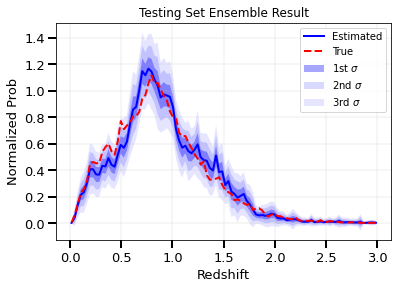

In [17]:
plot_pred_real(test)

#### We compare the true redshift distribution of the training set and the testing set and confirm that the testing set is well-represented

Text(0, 0.5, 'Normalized Prob')

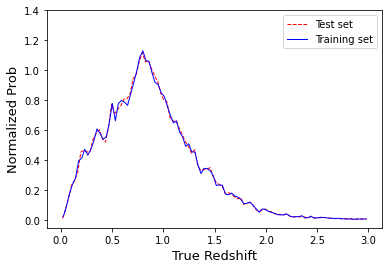

In [18]:
fig1, ax1 = plt.subplots(1)
testing = np.histogram(test[:,rz_ind],n_bins-1)
test_z = testing[1]
test_p = testing[0]/(len(test)*(z_max/(n_bins-1)))
test_z_space = (test_z[1:]-test_z[:-1])/2
test_z_mid = test_z[:-1]+test_z_space
ax1.plot(test_z_mid, test_p, '--',lw=1, label='Test set', color='red')
training = np.histogram(train[:,rz_ind],n_bins-1)
train_z = training[1]
train_p = training[0]/(len(train)*(z_max/(n_bins-1)))
train_z_space = (train_z[1:]-train_z[:-1])/2
train_z_mid = train_z[:-1]+train_z_space
ax1.plot(train_z_mid, train_p, lw=1, label='Training set', color='blue')
#ax1.set_title('True Redshift Distribution')
ax1.legend(loc='upper right')
xticks(np.arange(0, 3.1, step=0.5))
yticks(np.arange(0, 1.5, step=0.2))
ax1.set_xlabel('True Redshift',fontsize=tick_fontsize)
ax1.set_ylabel('Normalized Prob',fontsize=tick_fontsize)

## Individual galaxies result distribution analysis

In [12]:
# Get photoz_pdf info from our result

ave_prob_vec_tab = np.array(result_data_table['photoz_pdf'])
mode_table = np.array(result_data_table['photoz_mode'])

We plot the high redshift result:

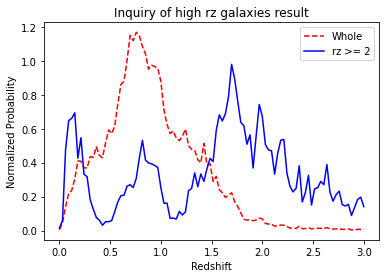

In [13]:
fig, m = plt.subplots(1)
m.plot(np.linspace(0,3,100),np.sum(ave_prob_vec_tab)/len(ave_prob_vec_tab), '--', label = 'Whole', color = 'red')
m.plot(np.linspace(0,3,100),
       np.sum(ave_prob_vec_tab[result_data_table['rz_real']>= 2])/len(ave_prob_vec_tab[result_data_table['rz_real']>= 2]),
      label = "rz >= 2", color = 'blue')
m.set_title("Inquiry of high rz galaxies result")
m.set_xlabel("Redshift")
m.set_ylabel("Normalized Probability")
m.legend()

We get mean redshift for each individual object by multiplying each midpoint with it's probability weight which takes into consideration the probability density function.

In [14]:
def get_ind_ave(ind_mean_table): 
    ave_table = []
    midstep = midpoints * ind_mean_table*(z_max/(n_bins-1))
    for i in range(len(midstep)): #can try to improve speed by doing array action
        ave_table += [np.sum(midstep[i])]
        if i%1000000 == 0: print(i) # It's quite slow so this indicates that it is running
    return ave_table

ave_table = get_ind_ave(ave_prob_vec_tab.tolist())

0
1000000
2000000
3000000
4000000
5000000
6000000
7000000
8000000


We also calculate the width of the photometric redshift distribution using the Interquartile range (IQR), Bias, Outlier Rate, and the sigma based on median absolute deviation (MAD) using https://github.com/LSSTDESC/PZDC1paper/tree/master/metric_scripts (Imported on 10th May 2020 and made minor edits for it to compile in Python 3 environment). 

IQR shows the width of the ez distribution; bias calculates the median of the ez samples; outlier rate is the number of galaxies with ez larger than either 0.06 or three sigmas. In these metrics ez is calculated by
ez = (photoz - specz)/(1+spec z)


In [15]:
# from https://github.com/LSSTDESC/PZDC1paper/tree/master/metric_scripts 
#Imported on 10th May 2020 and made minor edits for it to compile in Python 3 environment

import point_metrics

# calculate the width of the photometric redshift distribution

eval_point_metric = point_metrics.EvaluatePointStats(ave_table,result_data_table['rz_real'],result_data_table['mag_i'],imagcut=25.0)

# Interquartile range (IQR)
no_cut,with_cut = eval_point_metric.CalculateSigmaIQR()
print('Interquartile range (IQR) = '+ str(with_cut))

# Bias
no_cut,with_cut = eval_point_metric.CalculateBias()
print('Bias = '+ str(with_cut))

# Outlier Rate
no_cut,with_cut = eval_point_metric.CalculateOutlierRate()
print('Outlier Rate = '+ str(with_cut))

# Sigma based on median absolute deviation (MAD)
no_cut,with_cut = eval_point_metric.CalculateSigmaMAD()
print('Sigma based on MAD = '+ str(with_cut))

Interquartile range (IQR) = 0.06122202173207232
Bias = 0.02001711493357055
using 0.184 for cut for whole sample and 0.184 for magcut sample

Outlier Rate = 0.06273292231462914
Sigma based on MAD = 0.0584070059382604


We study two results from the probability vector: the mean redshift and the mode (redshift bin with the largest predicted probability). Because of the large quantity of galaxies, we plot log scale density plots for the mean and mode to better see the distributions. 

In [14]:
# Plot the probability density of mean/mode redshift for individual objects

def plot_MSE_pdf(mode_table):
    plt.hexbin(test[:, rz_ind],mode_table,bins = 'log', cmap = 'Blues')
    cb = plt.colorbar()
    xticks(np.arange(0, 3.1, step=0.5))
    yticks(np.arange(0, 3.1, step=0.5))
    plt.tick_params(axis='both', which='major', length = 8, width = 2,labelsize=tick_fontsize)
    plt.xlabel('True Redshift', fontsize=label_fontsize)
    plt.ylabel('Estimated Redshift', fontsize=label_fontsize)
    plt.xlim([0.0, z_max])
    plt.ylim([0.0, z_max])
    plt.axes().set_aspect('equal')
    return None 

/global/common/software/lsst/common/miniconda/py3.7-4.7.12.1-v1/envs/desc/lib/python3.7/site-packages/ipykernel/__main__.py:13: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.


Text(0.5, 1.0, 'Average')

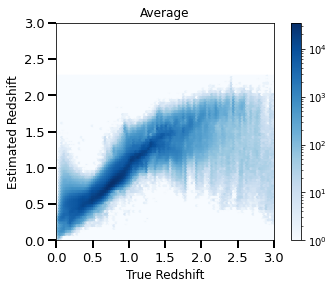

In [15]:
plot_MSE_pdf(ave_table)
plt.title('Average',fontsize=label_fontsize)
#Estimated Redshifts of Individual Galaxies

/global/common/software/lsst/common/miniconda/py3.7-4.7.12.1-v1/envs/desc/lib/python3.7/site-packages/ipykernel/__main__.py:13: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.


Text(0.5, 1.0, 'Mode')

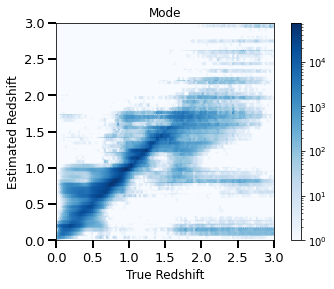

In [16]:
plot_MSE_pdf(mode_table)
plt.title('Mode')